# Topic Modeling: LDA and BERTopic (OpenRouter `text-embedding-3-large`)
This is the **parallel variant** of `topic_modeling.ipynb`.

The only difference is the embedding backend for BERTopic:
- **Original:** `paraphrase-multilingual-mpnet-base-v2` (local SentenceTransformer)
- **This notebook:** `openai/text-embedding-3-large` via [OpenRouter](https://openrouter.ai) API — 3072-dim embeddings, billed per token

Everything else (data loading, LDA, vectorizer, visualisations) is identical.

**Setup:** Set the environment variable `OPENROUTER_API_KEY` before running, or paste your key into the cell below.

In [1]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# Setup Thai font to fix missing glyphs in plots.
font_path = '../../../static/font/LINESeedSansTH_Rg.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
print(f"Font loaded: {font_prop.get_name()}")


Font loaded: LINE Seed Sans TH


In [2]:
# Install required libraries
# openai is used to call the OpenRouter-compatible embeddings endpoint.
# AttaCut is included because the upstream preprocessing tokenizes with engine='attacut'.
%pip install pandas numpy scikit-learn pythainlp attacut bertopic openai matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 32.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [openai]2m7/8 [openai]c]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import pandas as pd
import ast
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt

from bertopic import BERTopic
from openai import OpenAI

## 1. Data Loading and Preparation
This notebook uses the newer `sections_v2.csv` structure from `03_data_preparation/output`. The file stores one row per section with raw text, so we normalize the identifier columns and recreate the same Thai tokenization used upstream by `basic_eda.ipynb` via `data/preprocessed_data.csv`: AttaCut tokenization, Thai stopword removal, whitespace stripping, and punctuation/symbol filtering.


In [4]:
# Load the newer section-level dataset and tokenize with the same logic used for basic_eda's preprocessed tokens.
import re
from pythainlp.corpus.common import thai_stopwords
from pythainlp.tokenize import word_tokenize

df = pd.read_csv('../../output/sections_v2.csv', encoding='utf-8-sig', engine='python', on_bad_lines='skip')

# Normalize the sections_v2 schema to the column names expected below.
df = df.rename(columns={
    'doc_id': 'constitution_id',
})

df['text'] = df['text'].fillna('').astype(str)
df = df[df['text'].str.strip().ne('')].copy()

stopwords = set(thai_stopwords())

def preprocess_thai(text):
    tokens = word_tokenize(text, engine='attacut')

    clean_tokens = []
    for token in tokens:
        token = token.strip()
        if (
            token
            and token not in stopwords
            and not re.match(r'^[\W_]+$', token)
        ):
            clean_tokens.append(token)

    return clean_tokens

df['tokens'] = df['text'].apply(preprocess_thai)
df['joined_tokens'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))
df['word_count'] = df['tokens'].apply(len)
df = df[df['word_count'] > 0].reset_index(drop=True)

display_columns = ['section_id', 'constitution_id', 'year_th', 'chapter_number', 'section_number', 'text', 'joined_tokens']
display(df[display_columns].head())


,section_id,constitution_id,year_th,chapter_number,section_number,text,joined_tokens
0,const_2475_s_1,const_2475,2475,0,1,สยามประเทศเป็นราชอาณาจักรอันหนึ่งอันเดียว จะแบ...,สยาม ประเทศ ราชอาณาจักร แบ่งแยก ประชาชน สยาม ก...
1,const_2475_s_2,const_2475,2475,0,2,อำนาจอธิปไตยย่อมมาจากปวงชนชาวสยาม พระมหากษัตริ...,อำนาจ อธิปไตย ปวง ชน สยาม พระมหากษัตริย์ ประมุ...
2,const_2475_s_3,const_2475,2475,1,3,องค์พระมหากษัตริย์ดำรงอยู่ในฐานะอันเป็นที่เคาร...,องค์ พระมหากษัตริย์ ดำรง ฐานะ เคารพ สัก ใด ละเมิด
3,const_2475_s_4,const_2475,2475,1,4,พระมหากษัตริย์ต้องทรงเป็นพุทธมามกะ และทรงเป็นอ...,พระมหากษัตริย์ พุทธมามกะ อัครศาสนูปถัมภก
4,const_2475_s_5,const_2475,2475,1,5,พระมหากษัตริย์ทรงดำรงตำแหน่งจอมทัพ สยาม,พระมหากษัตริย์ ดำรง ตำแหน่ง จอมทัพ สยาม


In [5]:
# Define Custom Thai Legal Stopwords
from pythainlp.corpus import thai_stopwords
import pandas as pd

# Start with standard Thai stopwords
base_stopwords = list(thai_stopwords())

# Add legal-specific words that appear frequently but don't define topics
legal_noise = [
    "มาตรา", "ฉบับ", "พ.ศ.", "แห่ง", "ตาม", "นายกรัฐมนตรี", 
    "รัฐมนตรี", "สภา", "สมาชิก", "พระมหากษัตริย์", "อำนาจ",
    "บัญญัติ", "รักษา", "ประกาศ", "ระเบียบ", "ภายใต้", "กรณี"
]

custom_stopwords = list(set(base_stopwords + legal_noise))
print(f"Total stopwords: {len(custom_stopwords)}")


Total stopwords: 1044


## 2. Topic Modeling with LDA
**Latent Dirichlet Allocation (LDA)** is a classic method. It assumes:
* Every document is a mix of topics.
* Every topic is a mix of words.

To use LDA, we first need to count the words using a `CountVectorizer`. It creates a "Document-Term Matrix" (a big table of word counts).

In [6]:
# 2.1 Vectorize the text using List of Tokens (Friend's Style)
from sklearn.feature_extraction.text import CountVectorizer

# Following the EDA style: using the raw list of tokens
# We use tokenizer=lambda x: x because data is already a list of words
vectorizer = CountVectorizer(
    tokenizer=lambda x: x,
    token_pattern=None,
    lowercase=False,
    min_df=5, 
    max_df=0.9, 
    stop_words=custom_stopwords
)
X = vectorizer.fit_transform(df['tokens'])

# 2.2 Train the LDA Model
num_topics_lda = 5
lda_model = LatentDirichletAllocation(n_components=num_topics_lda, random_state=42)

print("Training LDA model...")
lda_model.fit(X)
print("Done!")


Training LDA model...
Done!


### Visualizing LDA Topics
We can look at the top words weight for each topic to understand what it's about.

Plotting top 10 words per topic in LDA:


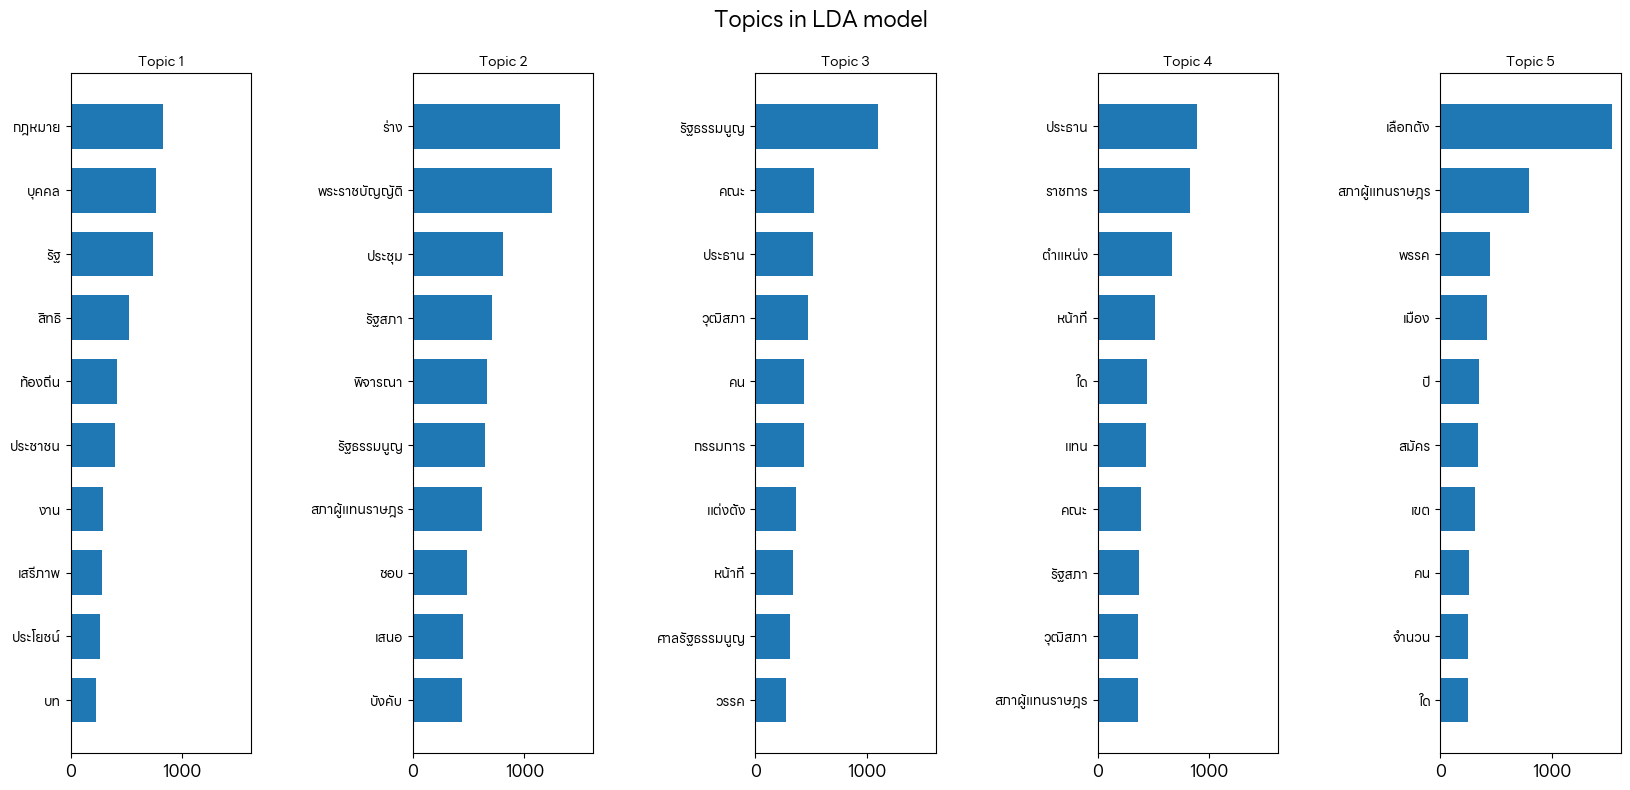

In [7]:
# Function to plot top words using matplotlib
def plot_top_words(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(1, 5, figsize=(20, 8), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 14}, fontproperties=font_prop)
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=12)
        
        # Use the custom Thai font for the labels
        for label in ax.get_yticklabels():
            label.set_fontproperties(font_prop)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.suptitle(title, fontsize=16, fontproperties=font_prop)
    plt.show()

print("Plotting top 10 words per topic in LDA:")
plot_top_words(lda_model, vectorizer.get_feature_names_out(), 10, "Topics in LDA model")


## 3. Topic Modeling with BERTopic (OpenRouter embeddings)
**BERTopic** uses embeddings to understand semantic meaning. Here we swap the local model for
**`openai/text-embedding-3-large`** served through OpenRouter — the same OpenAI-compatible API,
just routed through OpenRouter so you can use a single API key for many providers.

Key differences vs the original notebook:
- Embeddings are fetched via HTTP in parallel batches (no local GPU needed).
- The embedding dimension is **3072** instead of 768, which can improve cluster separation.
- Cost: ~$0.13 / million tokens (check OpenRouter pricing for the latest rate).

In [9]:
# 3.0 OpenRouter API key
# Set OPENROUTER_API_KEY in your shell, or paste the key string here (do NOT commit it).
OPENROUTER_API_KEY = "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"
if not OPENROUTER_API_KEY:
    raise ValueError("OPENROUTER_API_KEY is not set. Export it in your shell or paste it above.")

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

EMBED_MODEL = "openai/text-embedding-3-large"
BATCH_SIZE = 64  # OpenRouter accepts up to 2048 inputs per request; 64 keeps payloads small

In [10]:
# 3.1 Parallel batch embedding via OpenRouter
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

def embed_batch(batch: list[str]) -> list[list[float]]:
    response = client.embeddings.create(model=EMBED_MODEL, input=batch)
    # Items are returned in the same order as the input.
    return [item.embedding for item in sorted(response.data, key=lambda x: x.index)]

def embed_texts_parallel(texts: list[str], batch_size: int = BATCH_SIZE, max_workers: int = 8) -> np.ndarray:
    batches = [texts[i : i + batch_size] for i in range(0, len(texts), batch_size)]
    results: dict[int, list[list[float]]] = {}

    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {pool.submit(embed_batch, batch): idx for idx, batch in enumerate(batches)}
        for future in tqdm(as_completed(futures), total=len(futures), desc="Embedding batches"):
            idx = futures[future]
            results[idx] = future.result()

    ordered = []
    for i in range(len(batches)):
        ordered.extend(results[i])
    return np.array(ordered, dtype="float32")

# 1. Use raw text for semantic meaning
docs_for_embeddings = df['text'].tolist()

# 2. Join tokens for BERTopic's c-TF-IDF step
docs_for_ctfidf = df['tokens'].apply(lambda x: ' '.join(x)).tolist()

print(f"Generating embeddings for {len(docs_for_embeddings)} documents via OpenRouter ({EMBED_MODEL})...")
embeddings = embed_texts_parallel(docs_for_embeddings)
print(f"Embeddings shape: {embeddings.shape}")  # expected (n_docs, 3072)

Generating embeddings for 2797 documents via OpenRouter (openai/text-embedding-3-large)...


Embedding batches: 100%|██████████| 44/44 [00:08<00:00,  5.16it/s]


Embeddings shape: (2797, 3072)


In [15]:
# 3.2 Train BERTopic using the OpenRouter embeddings
# We pass precomputed embeddings, so BERTopic skips any internal embedding model.
#
# language=None is required: BERTopic._preprocess_text strips all non-ASCII chars
# when language="english" (the default), which removes every Thai character before
# the vectorizer runs and causes an empty vocabulary error.
vectorizer_model = CountVectorizer(
    token_pattern=r"[฀-๿]+",
    lowercase=False,
    min_df=2,
)

topic_model = BERTopic(
    language=None,
    vectorizer_model=vectorizer_model,
    verbose=True
)

print("Training BERTopic...")
topics, probs = topic_model.fit_transform(docs_for_ctfidf, embeddings=embeddings)
print("Done!")

2026-05-03 15:51:37,133 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Training BERTopic...


2026-05-03 15:51:53,821 - BERTopic - Dimensionality - Completed ✓
2026-05-03 15:51:53,822 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 15:51:53,875 - BERTopic - Cluster - Completed ✓
2026-05-03 15:51:53,878 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 15:51:53,941 - BERTopic - Representation - Completed ✓


Done!


In [16]:
# Let's look at the topics found by BERTopic
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))


,Topic,Count,Name,Representation,Representative_Docs
0,-1,314,-1_รัฐธรรมนูญ_มาตรา_บัญญัติ_บท,"[รัฐธรรมนูญ, มาตรา, บัญญัติ, บท, กฎหมาย, พระรา...",[วาระ บท บัญญัติ บังคับ กรณี เงื่อนไข 1 บท บัญ...
1,0,158,0_ส่งเสริม_พัฒนา_รัฐ_ระบบ,"[ส่งเสริม, พัฒนา, รัฐ, ระบบ, สนับสนุน, ประชาชน...",[รัฐ ต้องดําเนิน แนว นโยบาย สังคม สาธารณสุข ศึ...
2,1,101,1_กรรมการ_ตุลาการ_สรรหา_ศาลรัฐธรรมนูญ,"[กรรมการ, ตุลาการ, สรรหา, ศาลรัฐธรรมนูญ, เลือก...",[บุคคล ดํารงตําแหน่ง กรรมการ คณะ กรรมการ ตุลาก...
3,2,48,2_ร่าง_รัฐธรรมนูญ_สภานิติบัญญัติแห่งชาติ_กรรมา...,"[ร่าง, รัฐธรรมนูญ, สภานิติบัญญัติแห่งชาติ, กรร...",[ปัณรส สภา ร่าง รัฐธรรมนูญ ร่าง รัฐธรรมนูญ เสน...
4,3,46,3_ร้อง_วินิจฉัย_คณะตุลาการรัฐธรรมนูญ_สมาชิกภาพ,"[ร้อง, วินิจฉัย, คณะตุลาการรัฐธรรมนูญ, สมาชิกภ...",[สมาชิก วุฒิสภา สมาชิก สภาผู้แทนราษฎร จำนวน สา...
5,4,43,4_ท้องถิ่น_ปกครอง_องค์กร_บริหาร,"[ท้องถิ่น, ปกครอง, องค์กร, บริหาร, หลัก, ประชา...",[องค์กร ปกครอง ท้องถิ่น สภา ท้องถิ่น คณะ บริหา...
6,5,43,5_เสรีภาพ_สวัสดิภาพ_ชุมนุม_สงบเรียบร้อย,"[เสรีภาพ, สวัสดิภาพ, ชุมนุม, สงบเรียบร้อย, จำก...",[บุคคล เสรีภาพ เดินทาง เสรีภาพ เลือก ถิ่น ราชอ...
7,6,43,6_กรรมาธิการ_อำนาจ_กิจการ_วิสามัญ,"[กรรมาธิการ, อำนาจ, กิจการ, วิสามัญ, ข้อ, สามั...",[วุฒิสภา สภาผู้แทนราษฎร อำนาจ เลือก สมาชิก สภา...
8,7,40,7_เสรีภาพ_สิทธิ_บุคคล_เสมอ,"[เสรีภาพ, สิทธิ, บุคคล, เสมอ, เท่าเทียม, ศักดิ...",[บุคคล สิทธิ เสรีภาพ บังคับบท บัญญัติ รัฐธรรมน...
9,8,39,8_ห้าม_ลักษณะ_ติด_ปี,"[ห้าม, ลักษณะ, ติด, ปี, คุก, สมัคร, ประมาท, พิ...",[บุคคล ลักษณะ บุคคล ห้าม สิทธิ สมัคร เลือกตั้ง...


In [17]:
# Visualize the top words per topic as a bar chart (BERTopic natively supports Plotly)
fig = topic_model.visualize_barchart(top_n_topics=8)
fig


In [18]:
# Visualize the distance between topics
fig2 = topic_model.visualize_topics()
fig2.show()


In [19]:
# 4. Advanced BERTopic Visualizations
# Visualize the hierarchical structure of topics
hierarchical_topics = topic_model.hierarchical_topics(docs_for_ctfidf)
fig_hierarchy = topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)
fig_hierarchy.show()

# Visualize Topic Heatmap (Similarity Matrix)
fig_heatmap = topic_model.visualize_heatmap()
fig_heatmap.show()


100%|██████████| 113/113 [00:00<00:00, 906.06it/s]


In [ ]:
topic_model.generate_topic_labels()
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,398,-1_หลักการ_วินิจฉัย_ร่าง_เมือง,"[หลักการ, วินิจฉัย, ร่าง, เมือง, แวดล้อม, เสีย...",[ร่าง พระราชบัญญัติ ใด ชอบ รัฐสภา นายก รัฐมนตร...
1,0,68,0_เขต_จังหวัด_เลือกตั้ง_ราษฎร,"[เขต, จังหวัด, เลือกตั้ง, ราษฎร, แบ่ง, สมัคร, ...",[เลือกตั้ง สมาชิก สภาผู้แทนราษฎร เลือกตั้ง แบ่...
2,1,56,1_รัฐธรรมนูญ_ปฏิรูป_ร่าง_วาระ,"[รัฐธรรมนูญ, ปฏิรูป, ร่าง, วาระ, สภานิติบัญญัต...",[สภานิติบัญญัติแห่งชาติ ร่าง รัฐธรรมนูญ คณะ กร...
3,2,54,2_ร้อง_ตีความ_วินิจฉัย_คณะตุลาการรัฐธรรมนูญ,"[ร้อง, ตีความ, วินิจฉัย, คณะตุลาการรัฐธรรมนูญ,...",[สมาชิก วุฒิสภา สมาชิก สภาผู้แทนราษฎร จำนวน สิ...
4,3,47,3_ว่าง_อายุ_แทน_สลาก,"[ว่าง, อายุ, แทน, สลาก, วาระ, ตำแหน่ง, สมาชิกภ...",[ตำแหน่ง สมาชิก สภาผู้แทนราษฎร ว่าง ใด อายุ สภ...
5,4,42,4_เสรีภาพ_สิทธิ_เท่าเทียม_เสมอ,"[เสรีภาพ, สิทธิ, เท่าเทียม, เสมอ, บุคคล, ศักดิ...",[บุคคล เสมอ กฎหมาย คุ้มครอง กฎหมาย เท่าเทียม ช...
6,5,40,5_ราชอาณาจักรไทย_รัฐธรรมนูญ_พุทธศักราช_สภานิติ...,"[ราชอาณาจักรไทย, รัฐธรรมนูญ, พุทธศักราช, สภานิ...",[คณะ กรรมการร่าง รัฐธรรมนูญ รัฐธรรมนูญ ราชอาณา...
7,6,36,6_สัญชาติ_สมัคร_บ้าน_ไทย,"[สัญชาติ, สมัคร, บ้าน, ไทย, ปี, คุณสมบัติ, ทะเ...",[บุคคล คุณสมบัติ สิทธิ สมัคร เลือกตั้ง สมาชิก ...
8,7,36,7_นโยบาย_รับผิดชอบ_สถานโยบายแห่ง_แถลง,"[นโยบาย, รับผิดชอบ, สถานโยบายแห่ง, แถลง, บริหา...",[บริหาร ราชการ แผ่นดิน รัฐมนตรี ดำเนิน บท บัญญ...
9,8,36,8_ติด_ห้าม_สิทธิ_ล้มละลาย,"[ติด, ห้าม, สิทธิ, ล้มละลาย, คุก, บุคคล, ยา, เ...",[บุคคล ลักษณะ บุคคล ห้าม สิทธิ สมัคร เลือกตั้ง...
